# notebook for trying a few ideas

In [ ]:
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn

# Function to generate graphs with a cosine cycle pattern for nodes with random edges
def generate_cosine_pattern_graphs(num_graphs, max_nodes, avg_edges_per_node, period_days, start_size):
    graphs = []
    
    # Cosine pattern with a cycle (adjusted period for nodes)
    node_pattern = (max_nodes / 2) * (1 + np.cos(2 * np.pi * np.arange(num_graphs) / period_days))

    # Create graphs based on the node pattern
    for i in range(num_graphs):
        # Add more randomness to the number of nodes around the cosine pattern to increase variation
        num_nodes = start_size + max(2, min(int(node_pattern[i] + random.uniform(-0.3 * max_nodes, 0.3 * max_nodes)), max_nodes))

        # Create an empty graph with num_nodes
        G = nx.empty_graph(num_nodes)

        # Ensure each node has at least one edge
        for node in G.nodes():
            possible_edges = [edge for edge in nx.non_edges(G) if node in edge]
            if possible_edges:
                selected_edge = random.choice(possible_edges)
                G.add_edge(*selected_edge)
        
        # Randomly add additional edges based on the average number of edges per node
        num_edges = avg_edges_per_node * num_nodes
        possible_edges = list(nx.non_edges(G))
        if num_edges > len(possible_edges):
            num_edges = len(possible_edges)
        selected_edges = np.random.choice(len(possible_edges), int(num_edges), replace=False)
        G.add_edges_from([possible_edges[j] for j in selected_edges])

        # Print the graph details for verification
        print(f"Graph {i}: Nodes = {G.number_of_nodes()}, Edges = {G.number_of_edges()}")
        graphs.append(G)

    return graphs

# Parameters for graph generation
num_graphs = 100 # Number of graphs for training
max_nodes = 100  # Maximum number of nodes
avg_edges_per_node = 10  # Average number of edges per node
period_days = 30  # Set the period of the cosine cycle
start_size = 10  # Starting size for nodes

# Generate graphs with cosine patterns for nodes and random edges
synthetic_graphs = generate_cosine_pattern_graphs(num_graphs, max_nodes, avg_edges_per_node, period_days, start_size)

# Optional: Plot the number of nodes over time
node_pattern = (max_nodes / 2) * (1 + np.cos(2 * np.pi * np.arange(num_graphs) / period_days))
num_nodes_with_randomness = [
    start_size + max(2, min(int(n + np.random.uniform(-0.3 * max_nodes, 0.3 * max_nodes)), max_nodes))
    for n in node_pattern
]

plt.figure(figsize=(10, 6))
plt.plot(num_nodes_with_randomness, label="Number of Nodes", color="blue")
plt.title(f"Number of Nodes Over Time with {period_days}-Day Cosine Pattern")
plt.xlabel("Time (Graph Index)")
plt.ylabel("Number of Nodes")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn

# Node activation functions for degree-based filtration
def degree_activation(degrees, threshold):
    return {node for node, degree in degrees.items() if degree <= threshold}

# Compute global degree thresholds based on the degree distribution across all graphs
def compute_degree_thresholds(graphs, num_thresholds=10):
    all_degrees = []
    
    # Collect all degrees from all graphs
    for graph in graphs:
        degrees = dict(graph.degree()).values()
        all_degrees.extend(degrees)
    
    # Compute the thresholds based on quantiles of the degree distribution
    thresholds = np.percentile(all_degrees, np.linspace(0, 100, num_thresholds + 1)[1:])
    
    return thresholds

# Filtration function for generating embeddings (20-dimensional active data)
def graph_filtration(graph, metric, activation_func, thresholds):
    active_data = []
    
    for threshold in thresholds:
        active_node_set = activation_func(metric, threshold)
        active_edges = {edge for edge in graph.edges() if edge[0] in active_node_set and edge[1] in active_node_set}
        # Each filtration gives 2 features: (number of active edges, number of active nodes)
        active_data.extend([len(active_node_set), len(active_edges)])  # 2 features per threshold
    
    return active_data  # 20-dimensional vector

# Process the graphs and generate embeddings (each embedding is 20-dimensional)
def process_graphs_for_embeddings(graphs):
    all_embeddings = []
    
    # Compute global thresholds based on all graphs
    thresholds = compute_degree_thresholds(graphs, num_thresholds=10)
    
    for graph in graphs:
        metric = dict(graph.degree())  # Degree centrality as metric
        active_data = graph_filtration(graph, metric, degree_activation, thresholds)
        all_embeddings.append(active_data)  # 20-dimensional embedding
    
    return all_embeddings

# Parameters for graph generation (example from your previous code)
num_graphs = 1000  # Adjust the number of graphs for training
max_nodes = 100  # Maximum number of nodes
avg_edges_per_node = 5  # Average number of edges per node
period_days = 30  # Set the period of the cosine cycle
start_size = 10  # Starting size for nodes

# Generate synthetic graphs with cosine patterns for nodes and random edges
synthetic_graphs = generate_cosine_pattern_graphs(num_graphs, max_nodes, avg_edges_per_node, period_days, start_size)

# Generate embeddings from synthetic graphs using learned thresholds
embeddings = process_graphs_for_embeddings(synthetic_graphs)


In [156]:
class LSTMGRUPredictor(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=64 , num_layers_LSTM=1, num_layers_GRU=1):
        super(LSTMGRUPredictor, self).__init__()
        self.hidden_dim = hidden_dim
        self.hidden_dim_low_scaled = (self.hidden_dim//2)
        self.num_layers = num_layers
         # Define LSTM layers
        self.lstm1 = nn.LSTM(input_size=input_dim, hidden_size=self.hidden_dim, num_layers=num_layers_LSTM)
        self.lstm2 = nn.LSTM(input_size=self.hidden_dim, hidden_size=self.hidden_dim_low_scaled, num_layers=num_layers_LSTM)

        # Define GRU layers
        self.gru1 = nn.GRU(input_size=self.hidden_dim_low_scaled, hidden_size=self.hidden_dim_low_scaled, num_layers=num_layers_GRU)
        self.gru2 = nn.GRU(input_size=self.hidden_dim_low_scaled, hidden_size=self.hidden_dim_low_scaled, num_layers=num_layers_GRU)

        # Fully connected layers
        self.fc1 = nn.Linear(self.hidden_dim_low_scaled, 100)
        self.fc2 = nn.Linear(100, output_dim)

        # Activation function
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):

        # Forward pass through the LSTM layers
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)

        # Forward pass through the GRU layers
        x, _ = self.gru1(x)
        x, _ = self.gru2(x)

        # Pass through the fully connected layers
        x = x[:, -1, :]  # Take the output from the last time step
        x = self.fc1(x)
        x = self.fc2(x)
        
        return x

In [ ]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

# Assuming 'embeddings' is the full data you are working with
# Split the embeddings into training and test sets (80% train, 20% test)
train_embeddings, test_embeddings = train_test_split(embeddings, test_size=0.2, shuffle=False)

# Dataset class for embeddings with flexibility for both train and test sets
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings):
        self.embeddings = embeddings
    
    def __len__(self):
        return len(self.embeddings) - 1  # We want to predict the next embedding
    
    def __getitem__(self, idx):
        x = torch.Tensor(self.embeddings[idx]).unsqueeze(0)  # Add sequence dimension
        y = torch.Tensor(self.embeddings[idx + 1])  # Next embedding as target
        return x, y

# Create training and testing datasets and loaders
train_dataset = EmbeddingDataset(train_embeddings)
test_dataset = EmbeddingDataset(test_embeddings)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=False)  
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# LSTM + GRU model parameters
input_dim = 20  # 20-dimensional embeddings
hidden_dim = 128
output_dim = 20  # Predict the next 20-dimensional embedding
num_layers = 2

# Define the model (assuming LSTMGRUPredictor is defined elsewhere)
model = LSTMGRUPredictor(input_dim, output_dim, hidden_dim=hidden_dim,  num_layers_LSTM=num_layers, num_layers_GRU=num_layers)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

def train_model():
    model.train()
    epoch_loss = 0
    for x, y in train_loader:
        optimizer.zero_grad()

        # Reset hidden state for each batch (match batch size of x)
        hidden = (torch.zeros(num_layers, x.size(0), hidden_dim).to(x.device),
                  torch.zeros(num_layers, x.size(0), hidden_dim).to(x.device))

        output = model(x)


        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(train_loader)


# Training loop
num_epochs = 500
for epoch in range(num_epochs):
    loss = train_model()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss}")

# Set the starting index for the test set
split_index = len(train_embeddings)  # The start of the test set time index

# Evaluation on test set with hidden state management


In [ ]:
model.eval()
test_loss = 0
time_index = split_index  # Start time index at the beginning of the test set

predicted_embeddings = []

with torch.no_grad():
    hidden = None  # Initialize hidden state
    for x, y in test_loader:
        output = model(x)  # Maintain hidden state across time steps
        loss = criterion(output, y)
        test_loss += loss.item()
        
        # Print time index, predicted embedding, and real embedding
        for i in range(len(x)):
            predicted_embedding = output[i].numpy()
            real_embedding = y[i].numpy()
            print(f"Time Index:\t{time_index}\tPredicted Embedding:\t{'\t'.join(map(str, predicted_embedding))}\tReal Embedding:\t{'\t'.join(map(str, real_embedding))}")
            
            predicted_embeddings.append(predicted_embedding)  # add to list for reconstruction
            
            '''
            # Plot the predicted vs real embeddings
            plt.figure(figsize=(10, 6))
            plt.plot(predicted_embedding, label='Predicted Embedding', marker='o')
            plt.plot(real_embedding, label='Real Embedding', marker='x')
            
            
            plt.title('Predicted vs Real Embedding')
            plt.xlabel('Embedding Dimension')
            plt.ylabel('Value')
            plt.legend()
            
            plt.grid(True)
            plt.show()
            '''
            print("-" * 50)
            time_index += 1

print(f"Test Loss: {test_loss/len(test_loader)}")

# Reconstructing Graph (Three Methods)

In [280]:
import time
import networkx as nx
import numpy as np
import math
import random

Code used in all methods    

In [281]:
# The real graphs to compare to
true_graphs = synthetic_graphs[(int(len(synthetic_graphs) * (0.8)) + 1):]  # Can change based on train/test split size

Generate Models and Embeddings for Different Approaches

In [282]:
# Model for only nodes and edges
# Model for nodes, edges, betweenness
# Model for nodes, edges, diameter
# Model for nodes, edges, betweenness, diameter

In [283]:
# Get prediction embeddings
# Model for only nodes and edges
# Model for nodes, edges, betweenness
# Model for nodes, edges, density
# Model for nodes, edges, betweenness, density

Helper Functions

In [294]:
def round_features(embeddings, num_extra_features=0):
    """
    For the necessary features, rounds the embedding elements to the nearest integer

    Args:
        embeddings (list): The embeddings received from the model
        num_extra_features (int): If we are using features other than nodes and edges, 0 by default

    Returns:
        new_embeddings(list): The embeddings modified for the nodes and edges to be whole numbers
    """
    new_embeddings = []
    
    for embedding in embeddings:
        new_embedding = []
        for i in range(0, len(embedding), (2 + num_extra_features)):
            new_embedding.append(math.ceil(embedding[i]))  # Add the rounded num nodes
            new_embedding.append(math.ceil(embedding[i + 1]))  # Add the rounded num edges
            
            # Add other features that don't need to be rounded
            for j in range(0, num_extra_features):
                new_embedding.append(embedding[i + j])
    
        new_embeddings.append(new_embedding)
    
    return new_embeddings


def compute_features(graph):
    """
    Computes the features for a current graph to compare to the true features

    Args:
        graph (nx.Graph()): The current state of the graph in reconstruction

    Returns:
        features(list): The current features for the graph
    """
    features = []
    
    # Can add more calculations if desired
    features.append(nx.betweenness_centrality(graph))
    #features.append(nx.density(graph))
    
    return features


def determine_fitness(graph, true_features):
    """
    Computes the fitness score for the current state of the graph. Inspired by genetic algorithms in AI

    Args:
        graph (nx.Graph()): The current state of the graph in reconstruction
        true_features (list): The true features that we are aiming to create a graph to match

    Returns:
        diff_score(float): The difference between the current graphs embeddings and the true features
    """
    curr_features = compute_features(graph)
    
    diff_score = 0

    weights = [1]
    
    for weight, curr, target in zip(weights, curr_features, true_features):
        diff_score += weight * (np.abs(target - curr))  # Can modify if desired, for example: (target-curr) ** 2
    
    return diff_score


def compute_similarity(pred_graph, true_graph):
    """
    Computes a similarity score between the predicted graph and the true graph
    Might use a method inspired by Kadir's team

    Args:
        pred_graph (nx.Graph()): The current graph after reconstruction
        true_graph (nx.Graph()): The current true graph

    Returns:
        diff_score(float): The score of how different the two graphs are
    """
    
    # Prior calculations
    betweenness = nx.betweenness_centrality(true_graph)
    avg_true_betweenness = sum(betweenness.values()) / len(betweenness)
    betweenness = nx.betweenness_centrality(pred_graph)
    avg_pred_betweenness = sum(betweenness.values()) / len(betweenness)
    
    # Sample metrics, can add or remove as seen fit
    similarity_values = {
        'betweenness_diff': avg_true_betweenness - avg_pred_betweenness,
        'density_diff': nx.density(true_graph) - nx.density(pred_graph),
        'cycles_diff': len(nx.cycle_basis(true_graph)) - len(nx.cycle_basis(pred_graph)),
        'nodes_diff': nx.number_of_nodes(true_graph) - nx.number_of_nodes(pred_graph),
        'edge_diff': nx.number_of_edges(true_graph) - nx.number_of_edges(pred_graph),
        'cliques_diff': len(list(nx.find_cliques(true_graph))) - len(list(nx.find_cliques(pred_graph))),
    }
    
    # Display results
    for key, value in similarity_values.items():
        if value > 0:
            print(f'True predicted graph has a higher {key} value by: {value}')
        elif value < 0:
            print(f'True predicted graph has a lower {key} value by: {np.abs(value)}') 
        elif value == 0:
            print(f'True graph and predicted graph have exact same {key} value')
    
    print('stuck')
    
    # Compute the similarity between the graphs based on how many alterations/additions/deletions are required 
    edit_normalization = (nx.number_of_nodes(true_graph) + nx.number_of_nodes(pred_graph) + nx.number_of_edges(true_graph) + nx.number_of_edges(pred_graph)) / 2  # Can change, used if graphs are different sizes
    #edit_distance = nx.graph_edit_distance(true_graph, pred_graph) / edit_normalization  # 0 means perfect match; 1 or higher means highly different
    edit_distance_gen = nx.optimize_graph_edit_distance(true_graph, pred_graph)  # Less computationally intensive
    edit_distance = next(edit_distance_gen) / edit_normalization
    
    print('returning')
    return similarity_values, edit_distance


def display_edit_differences(edit_distances):
    """
    Displays how far off we were for each graph for each edit score

    Args:
        edit_distances (list): The number of edits required to reach each true graph

    Returns:
        None
    """
    timestamps = list(range(len(edit_distances)))

    # Plot the edit distances
    plt.figure(figsize=(10, 6))
    plt.plot(timestamps, edit_distances, marker='o', color='b', linestyle='-', linewidth=2, markersize=6)
    plt.xlabel("Timestamp")
    plt.ylabel("Edit Distance")
    plt.title("Edit Distances Across Graph Timestamps")
    plt.grid(True)

    # Show the plot
    plt.show()


def display_similarity_values(similarity_scores):
    """
    Displays how far off we were for each graph for each score metric

    Args:
        similarity_scores (dict): The similarity scores for each index

    Returns:
        None
    """
    metrics = list(similarity_scores.keys())
    values = list(similarity_scores.values())

    # Create the plot
    plt.figure(figsize=(10, 6))
    plt.bar(metrics, values, color='skyblue')
    plt.xlabel("Metrics")
    plt.ylabel("Difference Value")
    plt.title("Similarity Metric Differences Between True and Predicted Graphs")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Show the plot
    plt.tight_layout()
    plt.show()

Method 1: Assemble Graph In Order of Degree
SKIP FOR NOW

In [285]:
# Needs testing (currently does not give every node the correct number of edges)
def increasing_degree_fill(features):
    """
    Creates a graph such that we just fill the nodes as we see them in ascending filtrations

    Args:
        features (list): The provided features for a graph (assuming only node_num and edge_num at each filtration)

    Returns:
        graph (nx.Graph()): The newly created graph
    """
    graph = nx.Graph()
    
    # Base graph features
    num_nodes = 0  # Also works to label nodes for adding edges
    num_edges = 0  
    curr_degree = 1  # Allows quick referencing of node degree
            
    for i in range(0, len(features), 2):
        total_num_nodes = features[i]  # Stores the number of nodes supposed to be in the graph now
        total_num_edges = features[i + 1]  # Stores the number of edges supposed to be in the graph now
        
        num_nodes_to_add = total_num_nodes - num_nodes
        num_edges_to_add = total_num_edges - num_edges

        for j in range(num_nodes_to_add):
            graph.add_node(num_nodes, degree=curr_degree)
            num_nodes += 1  # Increment node id
            
        # Add edges to these new nodes
        edges_added = 0
        while edges_added < num_edges_to_add:
            unfilled_nodes = [node for node in graph.nodes if graph.degree(node) < graph.nodes[node]['degree']]  # Select all nodes that are not 'complete'
            
            # Cannot add additional edges
            if len(unfilled_nodes) < 2:
                break
            
            added_edges = False
            
            for source in unfilled_nodes:
                if graph.degree(source) >= graph.nodes[source]['degree']:
                    continue
                
                for target in unfilled_nodes:
                    # Assuming no self loops are allowed
                    if source == target:
                        continue
            
                    # Check if source and target dont have an edge
                    if not graph.has_edge(source,target):
                        #print(f'Adding an edge to a node of degree {graph.degree(target)} that needs degree {graph.nodes[target]['degree']}')
                        graph.add_edge(source, target)
                        
                        # Updates
                        edges_added += 1
                        num_edges += 1
                        added_edges = True
                        
                        # Halt condition
                        if graph.degree(source) >= graph.nodes[source]['degree']:
                            break
                        
                # Halt condition
                if edges_added >= num_edges_to_add:
                    print('Added enough edges')
                    break
            
            if not added_edges:
                break
            
        curr_degree += 1  # Increment the degree
        
    # Verify the graph was constructed properly
    unfilled_nodes = [node for node in graph.nodes if graph.nodes[node]['degree'] != graph.degree(node)]    
    if(len(unfilled_nodes)) > 0:
        for node in unfilled_nodes:
            print(f'Node #{node} is missing {(graph.nodes[node]['degree'] - graph.degree(node))} edges. Only has {graph.degree(node)} edges')
    '''       
    for node in graph.nodes():
        print(f'{node} with degree {graph.degree(node)} supposed to have {graph.nodes[node]['degree']}')
    '''
    print(f'There are supposed to be {features[-2]} nodes and {features[-1]} edges')
    print(f'There are actually {nx.number_of_nodes(graph)} nodes and {nx.number_of_edges(graph)} edges')
    
    pos = nx.spring_layout(graph)  # positions for all nodes
    nx.draw(graph, pos, with_labels=True, node_color='lightblue', node_size=800, font_size=10, font_color='black', font_weight='bold', edge_color='black')

    # Show the plot
    plt.title("Simple NetworkX Graph")
    plt.show()
    
    return graph

In [ ]:
predicted_embeddings = round_features(predicted_embeddings, num_extra_features=0)
edit_distances = []
similarity_scores = []  # Need to figure out what I really want to do with these

# Create a graph and compare it to the corresponding true graph
for graph_embedding, true_graph in zip(predicted_embeddings, true_graphs):
    curr_graph = increasing_degree_fill(graph_embedding)  # Create graph
    scores, edit_distance = compute_similarity(curr_graph, true_graph)  # Get metrics
    
    # Add scores to the list
    similarity_scores.append(scores)
    edit_distances.append(edit_distance)
    
    
# Display how far off we were for each metric as plt
display_edit_differences(edit_distances)

Method 2: Assemble Graph Greedily

In [288]:

def greedy_fill(features):
    """
    Creates a graph such that we fill the graph using a greedy-inspired algorithm

    Args:
        features (list): The provided features for a graph (assuming only node_num and edge_num at each filtration)

    Returns:
        graph (nx.Graph()): The newly created graph
    """
    graph = nx.Graph()
    
    # Base graph features
    num_nodes = 0  # Also works to label nodes for adding edges
    num_edges = 0  
    curr_degree = 1  # Allows quick referencing of node degree
            
    for i in range(0, len(features), 2):
        total_num_nodes = features[i]  # Stores the number of nodes supposed to be in the graph now
        num_nodes_to_add = total_num_nodes - num_nodes
        for j in range(num_nodes_to_add):
            graph.add_node(num_nodes, degree=curr_degree)
            num_nodes += 1
        
        curr_degree += 1  # Increment the degree        
    
    num_edges_to_add = features[-1] - num_edges
    
    while num_edges < num_edges_to_add:
        edges_added = False
    
        unfilled_nodes = [node for node in graph.nodes if graph.degree(node) < graph.nodes[node]['degree']]  # Select all nodes that are not 'complete'
        random.shuffle(unfilled_nodes)
        
        for source in unfilled_nodes:
            if graph.degree(source) >= graph.nodes[source]['degree']:
                continue
            
            for target in unfilled_nodes:
                # Assuming no self loops are allowed
                if source == target:
                    continue
        
                if graph.degree(source) >= graph.nodes[source]['degree'] or graph.degree(target) >= graph.nodes[target]['degree']:
                    continue
        
                # Check if source and target dont have an edge
                if not graph.has_edge(source,target):
                    #print(f'Adding an edge to a node of degree {graph.degree(target)} that needs degree {graph.nodes[target]['degree']}')
                    graph.add_edge(source, target)
                    
                    # Updates
                    edges_added = True
                    num_edges += 1
                    
                    # Halt condition
                    if graph.degree(source) >= graph.nodes[source]['degree']:
                        break
                    
                    # Halt condition
                    if edges_added >= num_edges_to_add:
                        break
                    
                    break
            
            if edges_added:
                break
        
        if not edges_added:
            print('Cant add any more edges')
            break
            
    # Verify the graph was constructed properly
    unfilled_nodes = [node for node in graph.nodes if graph.nodes[node]['degree'] != graph.degree(node)]    
    if(len(unfilled_nodes)) > 0:
        for node in unfilled_nodes:
            print(f'Node #{node} is missing {(graph.nodes[node]['degree'] - graph.degree(node))} edges. Only has {graph.degree(node)} edges')
    
    return graph    

returning
On graph number: 198
Cant add any more edges
Node #76 is missing 4 edges. Only has 5 edges
Node #80 is missing 1 edges. Only has 8 edges
True predicted graph has a lower betweenness_diff value by: 0.004155702668976632
True predicted graph has a higher density_diff value by: 0.26711429297636197
True predicted graph has a higher cycles_diff value by: 59
True predicted graph has a lower nodes_diff value by: 50
True predicted graph has a higher edge_diff value by: 9
True predicted graph has a lower cliques_diff value by: 31
stuck
returning
On graph number: 199


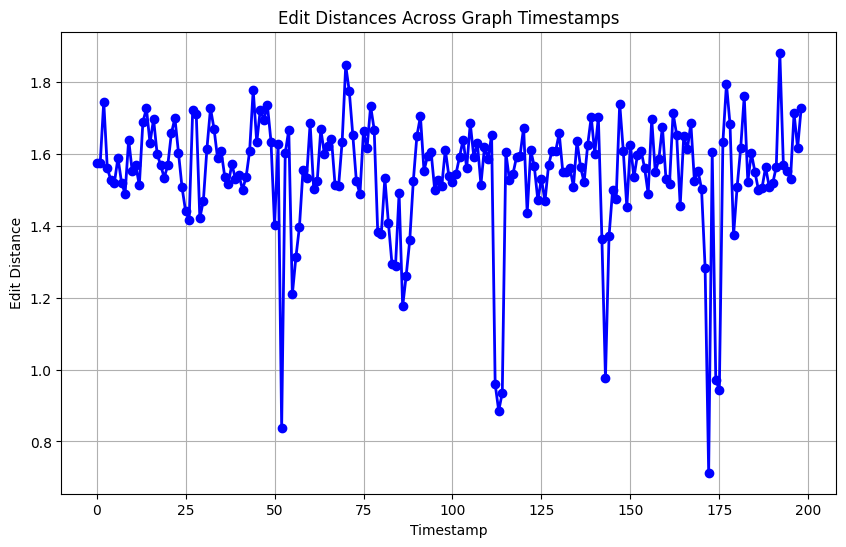

In [295]:
predicted_embeddings = round_features(predicted_embeddings, num_extra_features=0)
edit_distances = []
similarity_scores = [] 
graph_num = 1

# Create a graph and compare it to the corresponding true graph
for graph_embedding, true_graph in zip(predicted_embeddings, true_graphs):
    curr_graph = greedy_fill(graph_embedding)  # Create graph
    scores, edit_distance = compute_similarity(curr_graph, true_graph)  # Get metrics
    
    # Add scores to the list
    similarity_scores.append(scores)
    edit_distances.append(edit_distance)
    
    print(f'On graph number: {graph_num}')
    graph_num += 1
    
    
# Display how far off we were for each metric as plt
display_edit_differences(edit_distances)

Method 3: Assemble According to Metric (Betweenness)

In [17]:
def betweeness_assemble(features): 
    """
    Creates a graph such that we just fill the nodes as we see them

    Args:
        features (list): The provided features for a graph (assuming only node_num and edge_num at each filtration)

    Returns:
        graph (nx.Graph()): The newly created graph
    """
    graph = nx.Graph()
    
    for i in range(0, len(features), 3):
        nodes = features[i]
        edges = features[i + 1]
        betweeness = features[i + 2]
        
    return graph

In [ ]:
# Verification of rounding (Can remove once confirmed works)
print(f'Our predicted embeddings are {predicted_embeddings}')
predicted_embeddings = round_features(predicted_embeddings, num_extra_features=1)
print(f'Our rounded embeddings are {predicted_embeddings}')

In [ ]:
edit_distances = []
similarity_scores = [] 

# Create a graph and compare it to the corresponding true graph
for graph_embedding, true_graph in zip(predicted_embeddings, true_graphs):
    curr_graph = betweeness_assemble(graph_embedding)  # Create graph
    scores, edit_distance = compute_similarity(curr_graph, true_graph)  # Get metrics
    
    # Add scores to the list
    similarity_scores.append(scores)
    edit_distances.append(edit_distance)
    
    
# Display how far off we were for each metric as plt
display_edit_differences(edit_distances)
display_similarity_values(similarity_scores)

Method 4: Assemble According to Metric (Density)

In [ ]:

# Might switch to diameter
def density_assemble(features):
    graph = nx.Graph()
    
    for i in range(0, len(features), 3):
        nodes = features[i]
        edges = features[i + 1]
        densities = features[i + 2]

In [ ]:
edit_distances = []
similarity_scores = [] 

# Create a graph and compare it to the corresponding true graph
for graph_embedding, true_graph in zip(predicted_embeddings, true_graphs):
    curr_graph = density_assemble(graph_embedding)  # Create graph
    scores, edit_distance = compute_similarity(curr_graph, true_graph)  # Get metrics
    
    # Add scores to the list
    similarity_scores.append(scores)
    edit_distances.append(edit_distance)
    
    
# Display how far off we were for each metric as plt
display_edit_differences(edit_distances)
display_similarity_values(similarity_scores)

Method 5: Local Search Degree

In [277]:
def local_assemble(features):
    graph = nx.Graph()

    num_nodes = 0  # Also works to label nodes for adding edges
    num_edges = 0  
    curr_degree = 1  # Allows quick referencing of node degree
            
    for i in range(0, len(features), 2):
        total_num_nodes = features[i]  # Stores the number of nodes supposed to be in the graph now
        num_nodes_to_add = total_num_nodes - num_nodes
        for j in range(num_nodes_to_add):
            graph.add_node(num_nodes, degree=curr_degree)
            num_nodes += 1
        
        curr_degree += 1  # Increment the degree        
    
    # Step 2: Start local search for edge creation
    max_iterations = 1000
    iterations = 0
    improvements = True

    while iterations < max_iterations and improvements:
        improvements = False

        unfilled_nodes = [node for node in graph.nodes if graph.degree(node) < graph.nodes[node]['degree']]
        
        if len(unfilled_nodes) < 2:
            break

        # Randomly select a pair of nodes to attempt to connect
        source = random.choice(unfilled_nodes)
        target = random.choice(unfilled_nodes)

        if source != target and not graph.has_edge(source, target):
            # Check if adding this edge would help meet degree requirements
            if (graph.degree(source) < graph.nodes[source]['degree'] and graph.degree(target) < graph.nodes[target]['degree']):
                graph.add_edge(source, target)
                improvements = True

            # If adding the edge causes any node to exceed its degree, we might need to adjust
            for node in graph.nodes:
                if graph.degree(node) > graph.nodes[node]['degree']:
                    # Remove an edge to balance
                    edges = list(graph.edges(node))
                    if edges:
                        edge_to_remove = random.choice(edges)
                        graph.remove_edge(*edge_to_remove)

        iterations += 1

    # Verify the graph was constructed properly
    unfilled_nodes = [node for node in graph.nodes if graph.nodes[node]['degree'] != graph.degree(node)]    
    if(len(unfilled_nodes)) > 0:
        for node in unfilled_nodes:
            print(f'Node #{node} is missing {(graph.nodes[node]['degree'] - graph.degree(node))} edges. Only has {graph.degree(node)} edges')

    return graph

In [ ]:
edit_distances = []
similarity_scores = [] 

# Create a graph and compare it to the corresponding true graph
for graph_embedding, true_graph in zip(predicted_embeddings, true_graphs):
    curr_graph = local_assemble(graph_embedding)  # Create graph
    scores, edit_distance = compute_similarity(curr_graph, true_graph)  # Get metrics
    
    # Add scores to the list
    similarity_scores.append(scores)
    edit_distances.append(edit_distance)
    
    
# Display how far off we were for each metric as plt
display_edit_differences(edit_distances)
display_similarity_values(similarity_scores)

Method 6: Local Search Edges

Crazy Idea Notes

In [ ]:
# A GNN that trains using a function similar to curr.is_subgraph(true)
# Would need a normalization function to account for the difference between true and predicted embeddings
# Then it attempts to reconstruct a graph on its own
# Basically a combination of local search + GNN

# Read this more: https://arxiv.org/pdf/2110.00577 